## Pregunta 2 — Regresión (Características socioeconómicas y familiares)

¿Cómo influyen las condiciones socioeconómicas y familiares del estudiante en el puntaje global obtenido en las pruebas Saber 11?

In [1]:
# =========================================================
# Pregunta 2 — Regresión: características socioeconómicas y familiares
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
# =========================================================
# Carga de dataset limpio
# =========================================================

RUTA_DATOS = '/Users/anamariasanchezmejia/Downloads/saber11_limpio_base.csv'

df = pd.read_csv(RUTA_DATOS)

print(df.shape)

df.head()

(301723, 52)


,periodo,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_codigo_icfes,cole_depto_ubicacion,...,punt_global,anio,fami_personashogar_num,fami_cuartoshogar_num,fami_estratovivienda_num,estu_fechanacimiento_dt,edad,densidad_hogar,indice_tecnologico,indice_bienes_hogar
0,20194,sb11201940125751,urbano,no,a,academico,411769000127,411769000127,702142,bogota,...,310.0,2019,3.5,2,2,2002-11-14,16.1,1.750000,2,4
1,20194,sb11201940049452,urbano,no,a,academico,111279000168,111279000168,73031,bogota,...,217.0,2019,3.5,3,2,2000-02-13,18.9,1.166667,0,1
2,20194,sb11201940292128,urbano,no,a,academico,111279000966,111279000966,25163,bogota,...,261.0,2019,5.5,2,3,2001-10-16,17.2,2.750000,2,3
3,20194,sb11201940062240,urbano,no,a,academico,111001020095,111001020095,113043,bogota,...,289.0,2019,7.5,6,2,2002-05-20,16.6,1.250000,2,3
4,20194,sb11201940135822,urbano,no,a,tecnico/academico,111001013129,111001013129,90787,bogota,...,267.0,2019,1.5,1,3,2003-04-29,15.7,1.500000,2,2


In [3]:
# 1. Selección de variables para la pregunta

columnas_modelo = [
    "punt_global",
    "edad",
    "fami_estratovivienda_num",
    "fami_personashogar_num",
    "fami_cuartoshogar_num",
    "densidad_hogar",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_tieneinternet",
    "fami_tienecomputador",
    "fami_tieneautomovil",
    "fami_tienelavadora",
    "indice_tecnologico",
    "indice_bienes_hogar"
]

df_reg2 = df[columnas_modelo].copy()

print(df_reg2.shape)
df_reg2.head()

(301723, 14)


,punt_global,edad,fami_estratovivienda_num,fami_personashogar_num,fami_cuartoshogar_num,densidad_hogar,fami_educacionmadre,fami_educacionpadre,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,fami_tienelavadora,indice_tecnologico,indice_bienes_hogar
0,310.0,16.1,2,3.5,2,1.750000,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,si,si,si,si,2,4
1,217.0,18.9,2,3.5,3,1.166667,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,no,no,si,no,0,1
2,261.0,17.2,3,5.5,2,2.750000,secundaria (bachillerato) completa,secundaria (bachillerato) incompleta,si,si,no,si,2,3
3,289.0,16.6,2,7.5,6,1.250000,educacion profesional completa,educacion profesional completa,si,si,no,si,2,3
4,267.0,15.7,3,1.5,1,1.500000,tecnica o tecnologica completa,no sabe,si,si,no,no,2,2


In [4]:
# 2. Revisar faltantes

(df_reg2.isna().mean() * 100).sort_values(ascending=False)

fami_tieneautomovil         0.098103
fami_tienelavadora          0.028834
punt_global                 0.000000
edad                        0.000000
fami_estratovivienda_num    0.000000
fami_personashogar_num      0.000000
fami_cuartoshogar_num       0.000000
densidad_hogar              0.000000
fami_educacionmadre         0.000000
fami_educacionpadre         0.000000
fami_tieneinternet          0.000000
fami_tienecomputador        0.000000
indice_tecnologico          0.000000
indice_bienes_hogar         0.000000
dtype: float64

In [5]:
# 3. Eliminar faltantes solo para este modelo

df_reg2 = df_reg2.dropna().copy()

print("Dimensiones después de eliminar faltantes:", df_reg2.shape)

Dimensiones después de eliminar faltantes: (301366, 14)


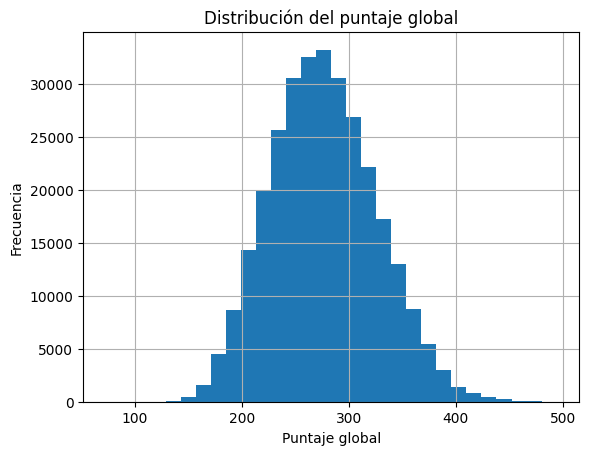

In [6]:
# 4. Análisis exploratorio básico

df_reg2["punt_global"].hist(bins=30)
plt.title("Distribución del puntaje global")
plt.xlabel("Puntaje global")
plt.ylabel("Frecuencia")
plt.show()

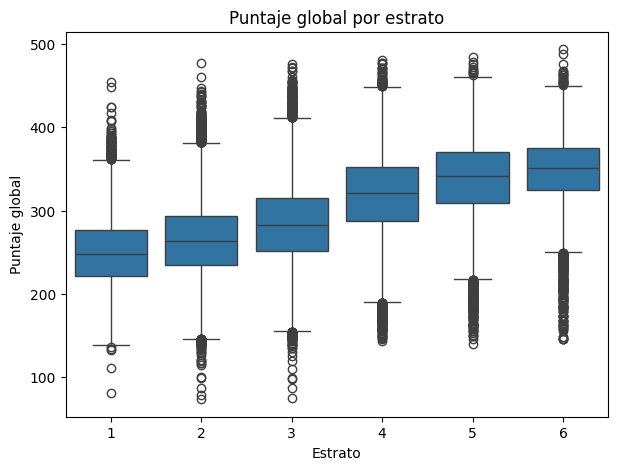

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_reg2, x="fami_estratovivienda_num", y="punt_global")
plt.title("Puntaje global por estrato")
plt.xlabel("Estrato")
plt.ylabel("Puntaje global")
plt.show()

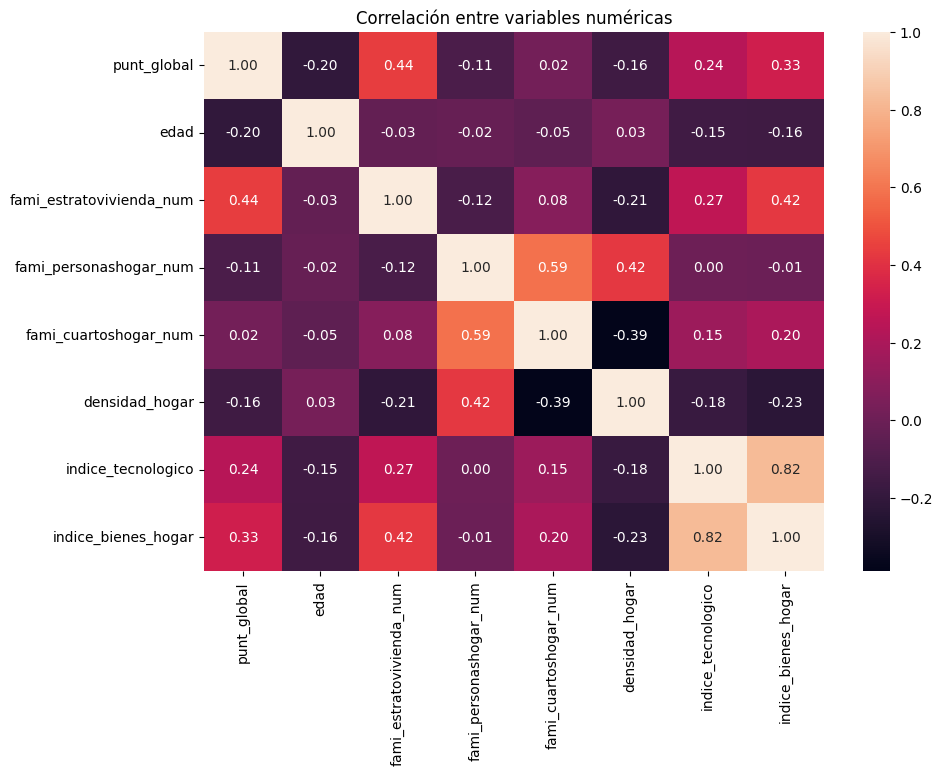

In [8]:
numericas = [
    "punt_global",
    "edad",
    "fami_estratovivienda_num",
    "fami_personashogar_num",
    "fami_cuartoshogar_num",
    "densidad_hogar",
    "indice_tecnologico",
    "indice_bienes_hogar"
]

plt.figure(figsize=(10, 7))
sns.heatmap(df_reg2[numericas].corr(), annot=True, fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

In [9]:
df_reg2["fami_educacionmadre"].value_counts(dropna=False)

fami_educacionmadre
secundaria (bachillerato) completa      83850
educacion profesional completa          45161
secundaria (bachillerato) incompleta    44850
tecnica o tecnologica completa          32518
primaria completa                       26833
primaria incompleta                     24167
postgrado                               15570
tecnica o tecnologica incompleta        11104
educacion profesional incompleta         9511
no sabe                                  4498
ninguno                                  3065
no aplica                                 239
Name: count, dtype: int64

In [10]:
df_reg2["fami_educacionpadre"].value_counts(dropna=False)

fami_educacionpadre
secundaria (bachillerato) completa      77081
secundaria (bachillerato) incompleta    42547
educacion profesional completa          39731
primaria incompleta                     31251
primaria completa                       28754
tecnica o tecnologica completa          22778
no sabe                                 16813
postgrado                               15843
tecnica o tecnologica incompleta         8501
educacion profesional incompleta         8070
ninguno                                  7921
no aplica                                2076
Name: count, dtype: int64

In [11]:
categoricas = [
    "fami_educacionmadre",
    "fami_educacionpadre"
]

df_reg2 = pd.get_dummies(
    df_reg2,
    columns=categoricas,
    drop_first=True
)

In [12]:
columnas_binarias = [
    "fami_tieneinternet",
    "fami_tienecomputador",
    "fami_tieneautomovil",
    "fami_tienelavadora"
]

for col in columnas_binarias:
    print("\n", col)
    print(df_reg2[col].value_counts(dropna=False))


 fami_tieneinternet
fami_tieneinternet
si    258094
no     43272
Name: count, dtype: int64

 fami_tienecomputador
fami_tienecomputador
si    255502
no     45864
Name: count, dtype: int64

 fami_tieneautomovil
fami_tieneautomovil
no    186867
si    114499
Name: count, dtype: int64

 fami_tienelavadora
fami_tienelavadora
si    269407
no     31959
Name: count, dtype: int64


In [13]:
mapa_binario = {
    "si": 1,
    "no": 0
}

for col in columnas_binarias:
    df_reg2[col] = df_reg2[col].map(mapa_binario)

In [14]:
for col in columnas_binarias:
    print("\n", col)
    print(df_reg2[col].value_counts(dropna=False))


 fami_tieneinternet
fami_tieneinternet
1    258094
0     43272
Name: count, dtype: int64

 fami_tienecomputador
fami_tienecomputador
1    255502
0     45864
Name: count, dtype: int64

 fami_tieneautomovil
fami_tieneautomovil
0    186867
1    114499
Name: count, dtype: int64

 fami_tienelavadora
fami_tienelavadora
1    269407
0     31959
Name: count, dtype: int64


In [15]:
df_reg2.head()

,punt_global,edad,fami_estratovivienda_num,fami_personashogar_num,fami_cuartoshogar_num,densidad_hogar,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,fami_tienelavadora,...,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) completa,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica incompleta
0,310.0,16.1,2,3.5,2,1.750000,1,1,1,1,...,False,False,False,False,False,False,False,True,False,False
1,217.0,18.9,2,3.5,3,1.166667,0,0,1,0,...,False,False,False,False,False,False,False,True,False,False
2,261.0,17.2,3,5.5,2,2.750000,1,1,0,1,...,False,False,False,False,False,False,False,True,False,False
3,289.0,16.6,2,7.5,6,1.250000,1,1,0,1,...,False,False,False,False,False,False,False,False,False,False
4,267.0,15.7,3,1.5,1,1.500000,1,1,0,0,...,False,False,True,False,False,False,False,False,False,False


In [16]:
bool_cols = df_reg2.select_dtypes(include="bool").columns

df_reg2[bool_cols] = df_reg2[bool_cols].astype(int)

In [17]:
df_reg2.dtypes

punt_global                                                 float64
edad                                                        float64
fami_estratovivienda_num                                      int64
fami_personashogar_num                                      float64
fami_cuartoshogar_num                                         int64
densidad_hogar                                              float64
fami_tieneinternet                                            int64
fami_tienecomputador                                          int64
fami_tieneautomovil                                           int64
fami_tienelavadora                                            int64
indice_tecnologico                                            int64
indice_bienes_hogar                                           int64
fami_educacionmadre_educacion profesional incompleta          int64
fami_educacionmadre_ninguno                                   int64
fami_educacionmadre_no aplica                   

In [18]:
variables_base = [
    "edad",
    "fami_estratovivienda_num",
    "fami_personashogar_num",
    "fami_cuartoshogar_num",
    "densidad_hogar",
    "fami_tieneinternet",
    "fami_tienecomputador",
    "fami_tieneautomovil",
    "fami_tienelavadora",
    "indice_tecnologico"
]

In [19]:
educacion_cols = [
    col for col in df_reg2.columns
    if (
        "fami_educacion" in col
        and "no sabe" not in col
        and "no aplica" not in col
    )
]

In [20]:
variables_modelo_b = variables_base + educacion_cols

In [21]:
X_base = df_reg2[variables_base]

In [22]:
X_extendido = df_reg2[variables_modelo_b]

In [23]:
y = df_reg2["punt_global"]

## MODELO A — Base socioeconómico

In [24]:
from sklearn.model_selection import train_test_split

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler_A = StandardScaler()

X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled = scaler_A.transform(X_test_A)

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluar(nombre, y_real, pred):

    mae = mean_absolute_error(y_real, pred)
    rmse = np.sqrt(mean_squared_error(y_real, pred))
    r2 = r2_score(y_real, pred)

    print(f"\nModelo: {nombre}")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 4))

    return [nombre, mae, rmse, r2]

In [27]:
from sklearn.linear_model import LinearRegression

lr_A = LinearRegression()

lr_A.fit(X_train_A_scaled, y_train_A)

pred_lr_A = lr_A.predict(X_test_A_scaled)

res_lr_A = evaluar(
    "Linear Regression A",
    y_test_A,
    pred_lr_A
)


Modelo: Linear Regression A
MAE : 34.24
RMSE: 42.57
R2  : 0.2572


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf_A = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_A.fit(X_train_A, y_train_A)

pred_rf_A = rf_A.predict(X_test_A)

res_rf_A = evaluar(
    "Random Forest A",
    y_test_A,
    pred_rf_A
)


Modelo: Random Forest A
MAE : 33.17
RMSE: 41.3
R2  : 0.3012


In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [30]:
modelo_nn_A = keras.Sequential([

    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)

])

In [31]:
modelo_nn_A.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [32]:
history_A = modelo_nn_A.fit(
    X_train_A_scaled,
    y_train_A,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 539us/step - loss: 4266.8613 - mae: 43.3611 - val_loss: 1728.2893 - val_mae: 33.3196
Epoch 2/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 539us/step - loss: 4266.8613 - mae: 43.3611 - val_loss: 1728.2893 - val_mae: 33.3196
Epoch 2/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 516us/step - loss: 1742.2568 - mae: 33.4390 - val_loss: 1718.8542 - val_mae: 33.1823
Epoch 3/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 516us/step - loss: 1742.2568 - mae: 33.4390 - val_loss: 1718.8542 - val_mae: 33.1823
Epoch 3/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 477us/step - loss: 1739.6796 - mae: 33.4134 - val_loss: 1717.2759 - val_mae: 33.2317
Epoch 4/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 477us/step - loss: 1739.6796 - mae: 33.4134 - val_loss: 1717.2759 - val_mae: 33.2317
Epoch 4/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 518us/step - loss: 1737.5015 - mae: 33.3904 - val_loss: 1715.8425 - val_mae: 33.1852
Epoch 5/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 518us/step - loss: 1737.5015 - mae: 33.3904 -

In [33]:
pred_nn_A = modelo_nn_A.predict(X_test_A_scaled)

res_nn_A = evaluar(
    "Neural Network A",
    y_test_A,
    pred_nn_A
)

1884/1884 ━━━━━━━━━━━━━━━━━━━━ 0s 233us/step
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 0s 233us/step

Modelo: Neural Network A
MAE : 33.46
RMSE: 41.66
R2  : 0.2888

Modelo: Neural Network A
MAE : 33.46
RMSE: 41.66
R2  : 0.2888


In [34]:
import pandas as pd

resultados_A = pd.DataFrame(
    [
        res_lr_A,
        res_rf_A,
        res_nn_A
    ],
    columns=["Modelo", "MAE", "RMSE", "R2"]
)

resultados_A

,Modelo,MAE,RMSE,R2
0,Linear Regression A,34.243868,42.573754,0.257234
1,Random Forest A,33.172983,41.295471,0.301168
2,Neural Network A,33.464254,41.658647,0.288822


In [35]:
import pandas as pd

importancias = pd.DataFrame({
    "Variable": X_base.columns,
    "Importancia": rf_A.feature_importances_
})

importancias.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
1,fami_estratovivienda_num,0.609662
0,edad,0.244404
7,fami_tieneautomovil,0.041701
9,indice_tecnologico,0.036447
2,fami_personashogar_num,0.027268
4,densidad_hogar,0.023044
3,fami_cuartoshogar_num,0.009513
8,fami_tienelavadora,0.004106
6,fami_tienecomputador,0.003016
5,fami_tieneinternet,0.000840


## Modelo Etendido con Educación padres

In [36]:
# Separación train/test
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_extendido,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
# Escalamiento
scaler_B = StandardScaler()

X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled = scaler_B.transform(X_test_B)

In [38]:
# 1. Regresión lineal — Modelo B

lr_B = LinearRegression()

lr_B.fit(X_train_B_scaled, y_train_B)

pred_lr_B = lr_B.predict(X_test_B_scaled)

res_lr_B = evaluar(
    "Linear Regression B",
    y_test_B,
    pred_lr_B
)


Modelo: Linear Regression B
MAE : 32.5
RMSE: 40.52
R2  : 0.327


In [39]:
# 2. Random Forest — Modelo B

rf_B = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_B.fit(X_train_B, y_train_B)

pred_rf_B = rf_B.predict(X_test_B)

res_rf_B = evaluar(
    "Random Forest B",
    y_test_B,
    pred_rf_B
)


Modelo: Random Forest B
MAE : 32.3
RMSE: 40.24
R2  : 0.3366


In [40]:
# 3. Red neuronal — Modelo B

modelo_nn_B = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

modelo_nn_B.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_B = modelo_nn_B.fit(
    X_train_B_scaled,
    y_train_B,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

pred_nn_B = modelo_nn_B.predict(X_test_B_scaled).flatten()

res_nn_B = evaluar(
    "Neural Network B",
    y_test_B,
    pred_nn_B
)

Epoch 1/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 494us/step - loss: 3950.9314 - mae: 41.3196 - val_loss: 1600.7502 - val_mae: 31.9733
Epoch 2/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 494us/step - loss: 3950.9314 - mae: 41.3196 - val_loss: 1600.7502 - val_mae: 31.9733
Epoch 2/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 464us/step - loss: 1610.8112 - mae: 32.1297 - val_loss: 1605.9996 - val_mae: 32.0081
Epoch 3/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 464us/step - loss: 1610.8112 - mae: 32.1297 - val_loss: 1605.9996 - val_mae: 32.0081
Epoch 3/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 481us/step - loss: 1602.2091 - mae: 32.0443 - val_loss: 1589.1852 - val_mae: 31.8699
Epoch 4/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 481us/step - loss: 1602.2091 - mae: 32.0443 - val_loss: 1589.1852 - val_mae: 31.8699
Epoch 4/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 464us/step - loss: 1599.1444 - mae: 32.0160 - val_loss: 1593.3228 - val_mae: 31.8740
Epoch 5/30
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 464us/step - loss: 1599.1444 - mae: 32.0160 -

In [41]:
# 4. Comparación completa A vs B

resultados_total = pd.DataFrame(
    [
        res_lr_A,
        res_rf_A,
        res_nn_A,
        res_lr_B,
        res_rf_B,
        res_nn_B
    ],
    columns=["Modelo", "MAE", "RMSE", "R2"]
)

resultados_total.sort_values("RMSE")

,Modelo,MAE,RMSE,R2
5,Neural Network B,32.094351,40.007576,0.344078
4,Random Forest B,32.303970,40.236096,0.336563
3,Linear Regression B,32.503755,40.524935,0.327004
1,Random Forest A,33.172983,41.295471,0.301168
2,Neural Network A,33.464254,41.658647,0.288822
0,Linear Regression A,34.243868,42.573754,0.257234


In [42]:
importancias_B = pd.DataFrame({
    "Variable": X_extendido.columns,
    "Importancia": rf_B.feature_importances_
})

importancias_B = importancias_B.sort_values(
    by="Importancia",
    ascending=False
)

importancias_B.head(20)

,Variable,Importancia
1,fami_estratovivienda_num,0.546079
0,edad,0.208806
21,fami_educacionpadre_postgrado,0.054121
12,fami_educacionmadre_postgrado,0.028137
9,indice_tecnologico,0.027180
7,fami_tieneautomovil,0.019404
15,fami_educacionmadre_secundaria (bachillerato) ...,0.016147
16,fami_educacionmadre_secundaria (bachillerato) ...,0.013078
14,fami_educacionmadre_primaria incompleta,0.012042
17,fami_educacionmadre_tecnica o tecnologica comp...,0.011345


In [43]:
modelo_nn_B

<Sequential name=sequential_1, built=True>

## Tarea 4 — Grilla de Hiperparámetros para Neural Network B con MLflow

In [51]:
import mlflow
import mlflow.keras

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("regresion_familiar_saber11")

print("Tracking URI:", mlflow.get_tracking_uri())

Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/trac

Tracking URI: file:./mlruns


In [52]:
import mlflow
import mlflow.keras

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("regresion_familiar_saber11")

# Separación train/test para la grilla
X_train, X_test, y_train, y_test = train_test_split(
    X_extendido, y, test_size=0.2, random_state=42
)

# Escalamiento
scaler_grid = StandardScaler()
X_train_scaled = scaler_grid.fit_transform(X_train)
X_test_scaled = scaler_grid.transform(X_test)

# Configuraciones de la grilla de hiperparámetros
configs = [
    {
        "nombre": "NN_B_base",
        "capas": [64, 32],
        "dropout": 0.0,
        "batch_size": 64,
        "epochs": 50
    },
    {
        "nombre": "NN_B_regularizada",
        "capas": [128, 64, 32],
        "dropout": 0.2,
        "batch_size": 64,
        "epochs": 80
    },
    {
        "nombre": "NN_B_profunda",
        "capas": [256, 128, 64, 32],
        "dropout": 0.2,
        "batch_size": 128,
        "epochs": 100
    }
]

# Definir experimento en MLflow
mlflow.set_experiment("regresion_familiar_saber11")

mejor_rmse = np.inf
mejor_modelo_grid = None
mejor_scaler_grid = None
mejor_columnas_grid = None
resultados_grid = []

for cfg in configs:
    with mlflow.start_run(run_name=cfg["nombre"]):
        print(f"\n{'='*60}")
        print(f"Entrenando: {cfg['nombre']}")
        print(f"{'='*60}")
        
        # Construir modelo
        model = keras.Sequential()
        for i, units in enumerate(cfg["capas"]):
            if i == 0:
                model.add(layers.Dense(units, activation="relu", input_dim=X_train.shape[1]))
            else:
                model.add(layers.Dense(units, activation="relu"))
            if cfg["dropout"] > 0:
                model.add(layers.Dropout(cfg["dropout"]))
        model.add(layers.Dense(1))

        model.compile(optimizer="adam", loss="mse", metrics=["mae"])

        # EarlyStopping para evitar sobreentrenamiento
        early = EarlyStopping(
            patience=10,
            restore_best_weights=True,
            monitor="val_loss"
        )

        # Entrenar modelo
        history = model.fit(
            X_train_scaled, y_train,
            validation_split=0.2,
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
            callbacks=[early],
            verbose=0
        )

        # Predicción y métricas
        pred = model.predict(X_test_scaled, verbose=0).flatten()
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)

        print(f"MAE : {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"R2  : {r2:.4f}")

        # Registrar parámetros en MLflow
        mlflow.log_param("capas", str(cfg["capas"]))
        mlflow.log_param("dropout", cfg["dropout"])
        mlflow.log_param("batch_size", cfg["batch_size"])
        mlflow.log_param("epochs", cfg["epochs"])
        mlflow.log_param("input_dim", X_train.shape[1])

        # Registrar métricas en MLflow
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        # Guardar modelo en MLflow
        mlflow.keras.log_model(model, "modelo_keras")

        # Guardar resultado
        resultados_grid.append([cfg["nombre"], mae, rmse, r2])

        # Actualizar mejor modelo
        if rmse < mejor_rmse:
            mejor_rmse = rmse
            mejor_modelo_grid = model
            mejor_scaler_grid = scaler_grid
            mejor_columnas_grid = X_extendido.columns.tolist()
            print(f"✓ Nuevo mejor modelo: RMSE = {mejor_rmse:.2f}")

print(f"\n{'='*60}")
print("RESUMEN DE RESULTADOS")
print(f"{'='*60}")


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/store/trac


Entrenando: NN_B_base


2026/05/25 14:57:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 14:57:25 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/05/25 14:57:25 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MAE : 32.02
RMSE: 39.91
R2  : 0.3472
✓ Nuevo mejor modelo: RMSE = 39.91

Entrenando: NN_B_regularizada
✓ Nuevo mejor modelo: RMSE = 39.91

Entrenando: NN_B_regularizada


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026/05/25 14:58:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 14:58:50 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/05/25 14:58:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 14:58:50 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MAE : 31.85
RMSE: 39.66
R2  : 0.3554
✓ Nuevo mejor modelo: RMSE = 39.66

Entrenando: NN_B_profunda
✓ Nuevo mejor modelo: RMSE = 39.66

Entrenando: NN_B_profunda


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026/05/25 15:00:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 15:00:40 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/05/25 15:00:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 15:00:40 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MAE : 31.85
RMSE: 39.68
R2  : 0.3547

RESUMEN DE RESULTADOS

RESUMEN DE RESULTADOS


In [53]:
# Crear tabla de resultados
resultados_grilla = pd.DataFrame(
    resultados_grid,
    columns=["Modelo", "MAE", "RMSE", "R2"]
)

resultados_grilla = resultados_grilla.sort_values("RMSE").reset_index(drop=True)

print(resultados_grilla.to_string(index=False))
print(f"\nMejor modelo: {resultados_grilla.iloc[0]['Modelo']}")
print(f"RMSE: {resultados_grilla.iloc[0]['RMSE']:.2f}")


           Modelo       MAE      RMSE       R2
NN_B_regularizada 31.850292 39.661499 0.355376
    NN_B_profunda 31.854051 39.681785 0.354717
        NN_B_base 32.023964 39.911774 0.347215

Mejor modelo: NN_B_regularizada
RMSE: 39.66


## Modelo final:

In [ ]:
# Guardar mejor modelo y artefactos
#print("\nGuardando artefactos del mejor modelo...")

#mejor_modelo_grid.save("modelo_final.keras")
#joblib.dump(mejor_scaler_grid, "scaler.pkl")
#joblib.dump(mejor_columnas_grid, "columnas_modelo.pkl")

#print("✓ modelo_final.keras")
#print("✓ scaler.pkl")
#print("✓ columnas_modelo.pkl")



Guardando artefactos del mejor modelo...
✓ modelo_final.keras
✓ scaler.pkl
✓ columnas_modelo.pkl
